# Modelo de Clasificación - Dataset Wine

Este notebook construye un modelo de clasificación para el dataset wine de sklearn.

In [2]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Cargar y Explorar el Dataset

In [3]:
# Cargar el dataset wine
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

# Mostrar información del dataset
print("Dimensiones del dataset:")
print(f"Características: {X.shape}")
print(f"Muestras: {X.shape[0]}")
print(f"Clases: {len(np.unique(y))}")
print("\nPrimeras filas:")
print(X.head())
print("\nInformación de clases:")
print(f"Distribución de clases: {np.bincount(y)}")

Dimensiones del dataset:
Características: (178, 13)
Muestras: 178
Clases: 3

Primeras filas:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1

In [4]:
# Estadísticas descriptivas del dataset
print("\nEstadísticas descriptivas:")
print(X.describe())


Estadísticas descriptivas:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453        

## 2. División de Datos en Entrenamiento y Prueba

In [5]:
# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]}")
print(f"\nDistribución de clases en entrenamiento: {np.bincount(y_train)}")
print(f"Distribución de clases en prueba: {np.bincount(y_test)}")

Tamaño del conjunto de entrenamiento: 142
Tamaño del conjunto de prueba: 36

Distribución de clases en entrenamiento: [47 57 38]
Distribución de clases en prueba: [12 14 10]


## 2.1 Definir Niveles de Profundidad

In [6]:
# Definir los niveles de profundidad a probar
profundidades = [3, 5, 7, 10, 15]
print(f"Profundidades a evaluar: {profundidades}")

Profundidades a evaluar: [3, 5, 7, 10, 15]


## 3. Entrenar Modelos de Clasificación

In [7]:
### 3.1 Entrenamiento de Árbol de Decisión con Diferentes Profundidades
# Entrenar modelos de Árbol de Decisión con diferentes profundidades
accuracies_dt = {}
modelos_dt = {}

for prof in profundidades:
    dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=prof)
    dt_classifier.fit(X_train, y_train)
    y_pred_dt_temp = dt_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_dt_temp)
    accuracies_dt[prof] = accuracy
    modelos_dt[prof] = dt_classifier

# Usar el modelo con profundidad 5 para evaluación detallada
dt_classifier = modelos_dt[5]
y_pred_dt = dt_classifier.predict(X_test)
dt_accuracy = accuracies_dt[5]

print("=== Árbol de Decisión (profundidad=5) ===")
print(f"Precisión: {dt_accuracy:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_dt, target_names=wine.target_names))

=== Árbol de Decisión (profundidad=5) ===
Precisión: 0.9444

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [8]:
### 3.2 Entrenamiento de Random Forest con Diferentes Profundidades
# Entrenar modelos de Random Forest con diferentes profundidades
accuracies_rf = {}
modelos_rf = {}

for prof in profundidades:
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=prof)
    rf_classifier.fit(X_train, y_train)
    y_pred_rf_temp = rf_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_rf_temp)
    accuracies_rf[prof] = accuracy
    modelos_rf[prof] = rf_classifier

# Usar el modelo con profundidad 5 para evaluación detallada
rf_classifier = modelos_rf[5]
y_pred_rf = rf_classifier.predict(X_test)
rf_accuracy = accuracies_rf[5]

print("=== Random Forest (profundidad=5) ===")
print(f"Precisión: {rf_accuracy:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=wine.target_names))

=== Random Forest (profundidad=5) ===
Precisión: 1.0000

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 4. Visualización de Matrices de Confusión

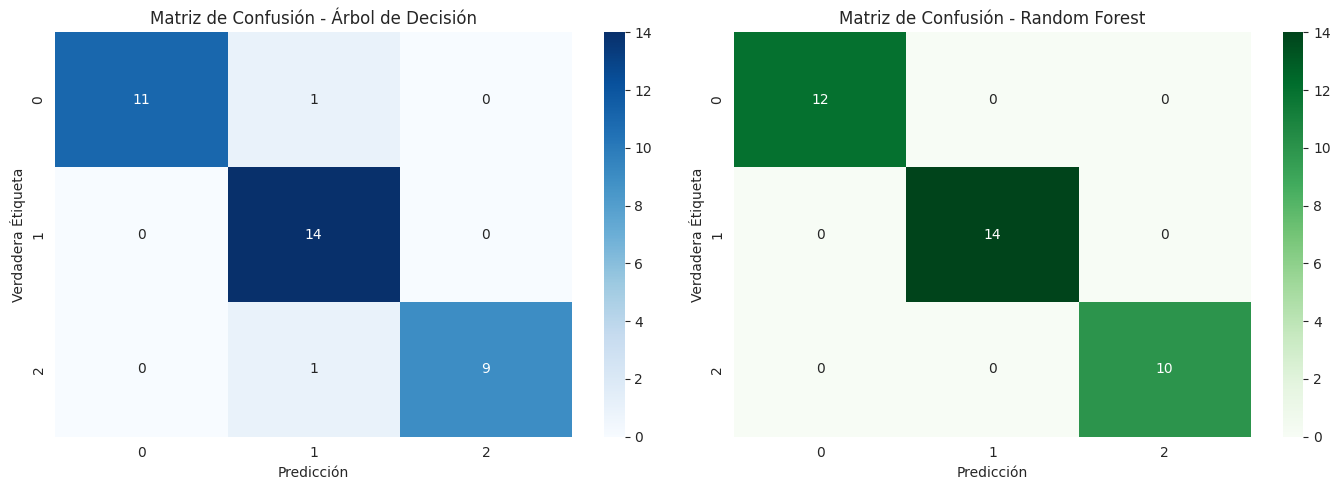

In [9]:
# Crear figuras para las matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión para Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión - Árbol de Decisión')
axes[0].set_ylabel('Verdadera Étiqueta')
axes[0].set_xlabel('Predicción')

# Matriz de confusión para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión - Random Forest')
axes[1].set_ylabel('Verdadera Étiqueta')
axes[1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

## 5. Comparación de Modelos

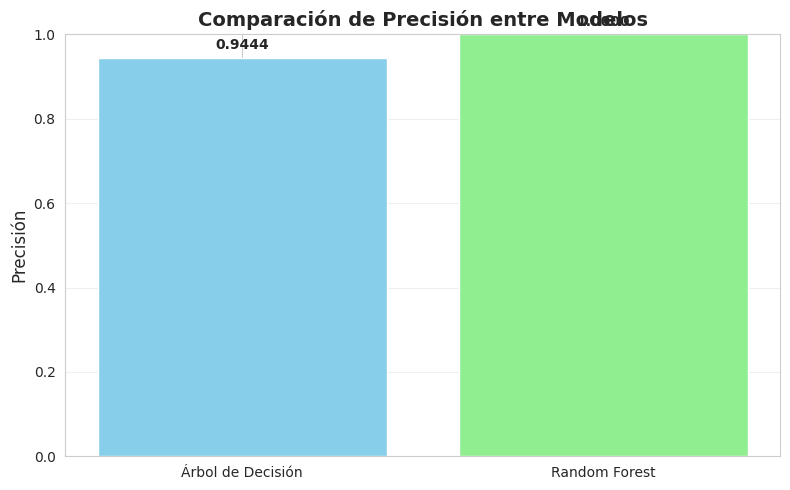


Resumen de precisiones:
Árbol de Decisión: 0.9444
Random Forest: 1.0000


In [10]:
# Comparar precisión de ambos modelos
modelos = ['Árbol de Decisión', 'Random Forest']
precisiones = [dt_accuracy, rf_accuracy]

plt.figure(figsize=(8, 5))
barras = plt.bar(modelos, precisiones, color=['skyblue', 'lightgreen'])
plt.ylabel('Precisión', fontsize=12)
plt.title('Comparación de Precisión entre Modelos', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (modelo, precision) in enumerate(zip(modelos, precisiones)):
    plt.text(i, precision + 0.02, f'{precision:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nResumen de precisiones:")
print(f"Árbol de Decisión: {dt_accuracy:.4f}")
print(f"Random Forest: {rf_accuracy:.4f}")

## 6. Análisis de Diferente Profundidades

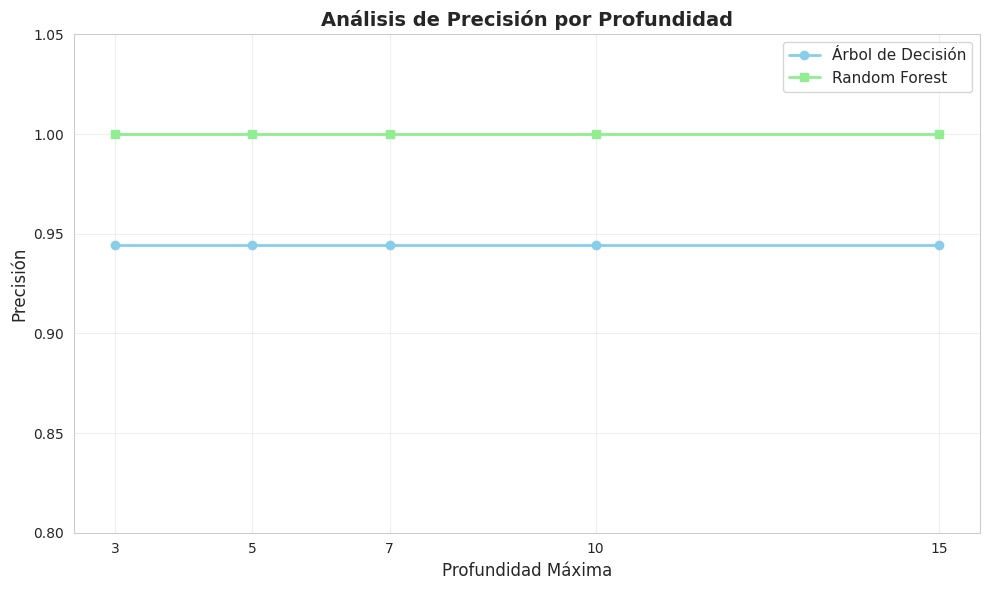


=== Precisión por Profundidad ===
Profundidad  Árbol Decisión     Random Forest     
------------------------------------------------
3            0.9444             1.0000            
5            0.9444             1.0000            
7            0.9444             1.0000            
10           0.9444             1.0000            
15           0.9444             1.0000            


In [11]:
# Comparar precisiones para diferentes profundidades
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(profundidades, [accuracies_dt[p] for p in profundidades], marker='o', linewidth=2, label='Árbol de Decisión', color='skyblue')
ax.plot(profundidades, [accuracies_rf[p] for p in profundidades], marker='s', linewidth=2, label='Random Forest', color='lightgreen')

ax.set_xlabel('Profundidad Máxima', fontsize=12)
ax.set_ylabel('Precisión', fontsize=12)
ax.set_title('Análisis de Precisión por Profundidad', fontsize=14, fontweight='bold')
ax.set_xticks(profundidades)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0.8, 1.05])

plt.tight_layout()
plt.show()

# Mostrar tabla comparativa
print("\n=== Precisión por Profundidad ===")
print(f"{'Profundidad':<12} {'Árbol Decisión':<18} {'Random Forest':<18}")
print("-" * 48)
for prof in profundidades:
    print(f"{prof:<12} {accuracies_dt[prof]:<18.4f} {accuracies_rf[prof]:<18.4f}")

## 7. Validación Cruzada

In [12]:
### 7.1 Validación Cruzada para Árbol de Decisión
# Realizar validación cruzada con k=5 pliegues
cv_scores_dt = {}
for prof in profundidades:
    dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=prof)
    scores = cross_val_score(dt_classifier, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_dt[prof] = scores
    print(f"Profundidad {prof} - Árbol de Decisión")
    print(f"  Precisión CV: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  Puntuaciones: {[f'{s:.4f}' for s in scores]}\n")


Profundidad 3 - Árbol de Decisión
  Precisión CV: 0.9232 (+/- 0.0456)
  Puntuaciones: ['0.8621', '0.8966', '0.9286', '0.9286', '1.0000']

Profundidad 5 - Árbol de Decisión
  Precisión CV: 0.9163 (+/- 0.0514)
  Puntuaciones: ['0.8621', '0.8621', '0.9286', '0.9286', '1.0000']

Profundidad 7 - Árbol de Decisión
  Precisión CV: 0.9163 (+/- 0.0514)
  Puntuaciones: ['0.8621', '0.8621', '0.9286', '0.9286', '1.0000']

Profundidad 10 - Árbol de Decisión
  Precisión CV: 0.9163 (+/- 0.0514)
  Puntuaciones: ['0.8621', '0.8621', '0.9286', '0.9286', '1.0000']

Profundidad 15 - Árbol de Decisión
  Precisión CV: 0.9163 (+/- 0.0514)
  Puntuaciones: ['0.8621', '0.8621', '0.9286', '0.9286', '1.0000']



In [13]:
### 7.2 Validación Cruzada para Random Forest
# Realizar validación cruzada con k=5 pliegues
cv_scores_rf = {}
for prof in profundidades:
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=prof)
    scores = cross_val_score(rf_classifier, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_rf[prof] = scores
    print(f"Profundidad {prof} - Random Forest")
    print(f"  Precisión CV: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  Puntuaciones: {[f'{s:.4f}' for s in scores]}\n")


Profundidad 3 - Random Forest
  Precisión CV: 0.9862 (+/- 0.0276)
  Puntuaciones: ['1.0000', '0.9310', '1.0000', '1.0000', '1.0000']

Profundidad 5 - Random Forest
  Precisión CV: 0.9862 (+/- 0.0276)
  Puntuaciones: ['1.0000', '0.9310', '1.0000', '1.0000', '1.0000']

Profundidad 7 - Random Forest
  Precisión CV: 0.9862 (+/- 0.0276)
  Puntuaciones: ['1.0000', '0.9310', '1.0000', '1.0000', '1.0000']

Profundidad 10 - Random Forest
  Precisión CV: 0.9862 (+/- 0.0276)
  Puntuaciones: ['1.0000', '0.9310', '1.0000', '1.0000', '1.0000']

Profundidad 15 - Random Forest
  Precisión CV: 0.9862 (+/- 0.0276)
  Puntuaciones: ['1.0000', '0.9310', '1.0000', '1.0000', '1.0000']



### 7.3 Visualización de Resultados de Validación Cruzada

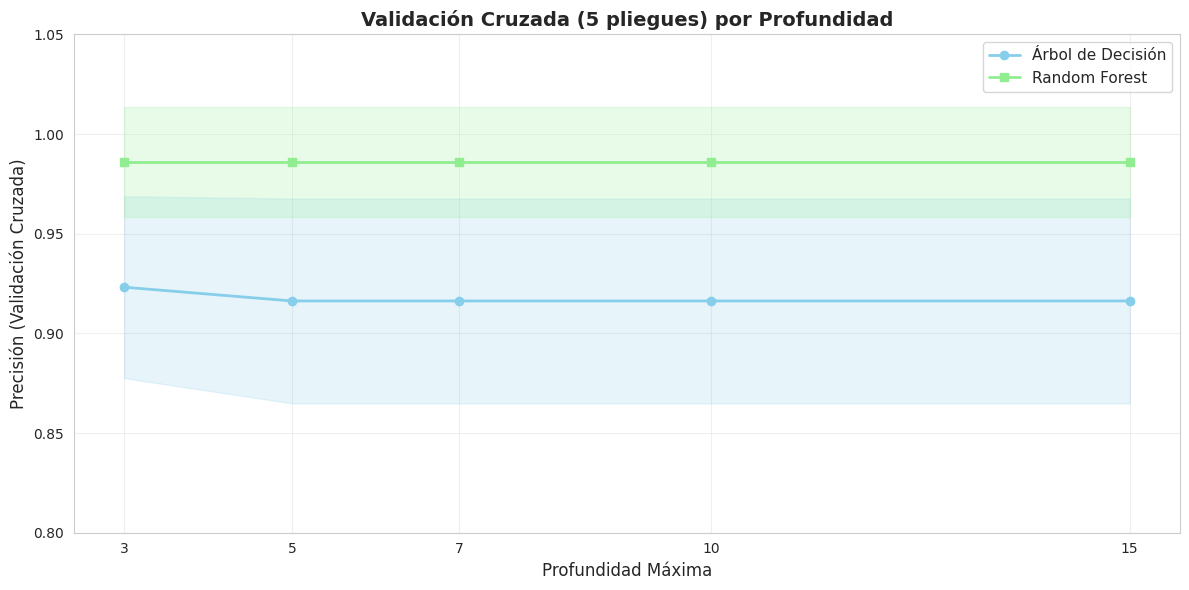


=== Validación Cruzada (5 pliegues) ===
Profundidad  DT Media     DT Desv.Est     RF Media     RF Desv.Est    
------------------------------------------------------------------
3            0.9232       0.0456          0.9862       0.0276         
5            0.9163       0.0514          0.9862       0.0276         
7            0.9163       0.0514          0.9862       0.0276         
10           0.9163       0.0514          0.9862       0.0276         
15           0.9163       0.0514          0.9862       0.0276         


In [14]:
# Gráfico de validación cruzada con intervalos de confianza
fig, ax = plt.subplots(figsize=(12, 6))

dt_means = [cv_scores_dt[p].mean() for p in profundidades]
dt_stds = [cv_scores_dt[p].std() for p in profundidades]

rf_means = [cv_scores_rf[p].mean() for p in profundidades]
rf_stds = [cv_scores_rf[p].std() for p in profundidades]

# Graficar líneas con áreas sombreadas para las desviaciones estándar
ax.plot(profundidades, dt_means, marker='o', linewidth=2, label='Árbol de Decisión', color='skyblue')
ax.fill_between(profundidades, 
                [m - s for m, s in zip(dt_means, dt_stds)],
                [m + s for m, s in zip(dt_means, dt_stds)],
                alpha=0.2, color='skyblue')

ax.plot(profundidades, rf_means, marker='s', linewidth=2, label='Random Forest', color='lightgreen')
ax.fill_between(profundidades,
                [m - s for m, s in zip(rf_means, rf_stds)],
                [m + s for m, s in zip(rf_means, rf_stds)],
                alpha=0.2, color='lightgreen')

ax.set_xlabel('Profundidad Máxima', fontsize=12)
ax.set_ylabel('Precisión (Validación Cruzada)', fontsize=12)
ax.set_title('Validación Cruzada (5 pliegues) por Profundidad', fontsize=14, fontweight='bold')
ax.set_xticks(profundidades)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0.8, 1.05])

plt.tight_layout()
plt.show()

# Tabla comparativa
print("\n=== Validación Cruzada (5 pliegues) ===")
print(f"{'Profundidad':<12} {'DT Media':<12} {'DT Desv.Est':<15} {'RF Media':<12} {'RF Desv.Est':<15}")
print("-" * 66)
for prof in profundidades:
    dt_mean = cv_scores_dt[prof].mean()
    dt_std = cv_scores_dt[prof].std()
    rf_mean = cv_scores_rf[prof].mean()
    rf_std = cv_scores_rf[prof].std()
    print(f"{prof:<12} {dt_mean:<12.4f} {dt_std:<15.4f} {rf_mean:<12.4f} {rf_std:<15.4f}")


In [15]:
### 7.4 Resumen: Entrenamiento vs Validación Cruzada
# Comparar precisión de test vs validación cruzada para profundidad 5
print("\n=== Comparación: Test Set vs Validación Cruzada (Profundidad=5) ===")
print(f"\nÁrbol de Decisión:")
print(f"  Precisión en Test Set: {accuracies_dt[5]:.4f}")
print(f"  Precisión CV (media):  {cv_scores_dt[5].mean():.4f}")
print(f"  Desviación estándar:   {cv_scores_dt[5].std():.4f}")

print(f"\nRandom Forest:")
print(f"  Precisión en Test Set: {accuracies_rf[5]:.4f}")
print(f"  Precisión CV (media):  {cv_scores_rf[5].mean():.4f}")
print(f"  Desviación estándar:   {cv_scores_rf[5].std():.4f}")

# Identificar mejor profundidad basado en CV
best_depth_dt = max(profundidades, key=lambda p: cv_scores_dt[p].mean())
best_depth_rf = max(profundidades, key=lambda p: cv_scores_rf[p].mean())

print(f"\n=== Mejores Profundidades (según Validación Cruzada) ===")
print(f"Árbol de Decisión: profundidad={best_depth_dt} (precisión CV: {cv_scores_dt[best_depth_dt].mean():.4f})")
print(f"Random Forest: profundidad={best_depth_rf} (precisión CV: {cv_scores_rf[best_depth_rf].mean():.4f})")



=== Comparación: Test Set vs Validación Cruzada (Profundidad=5) ===

Árbol de Decisión:
  Precisión en Test Set: 0.9444
  Precisión CV (media):  0.9163
  Desviación estándar:   0.0514

Random Forest:
  Precisión en Test Set: 1.0000
  Precisión CV (media):  0.9862
  Desviación estándar:   0.0276

=== Mejores Profundidades (según Validación Cruzada) ===
Árbol de Decisión: profundidad=3 (precisión CV: 0.9232)
Random Forest: profundidad=3 (precisión CV: 0.9862)


## 8. Múltiples Métricas de Evaluación

In [16]:
### 8.1 Cálculo de Múltiples Métricas
# Calcular múltiples métricas para ambos modelos con profundidad 5

# Métricas para Árbol de Decisión
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

# Métricas para Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

# Crear tabla comparativa de métricas
metricas_df = pd.DataFrame({
    'Métrica': ['Precisión', 'Recall', 'F1-Score', 'Exactitud'],
    'Árbol Decisión': [dt_precision, dt_recall, dt_f1, dt_accuracy],
    'Random Forest': [rf_precision, rf_recall, rf_f1, rf_accuracy]
})

print("=" * 60)
print("Comparativa de Métricas (Profundidad = 5)")
print("=" * 60)
print(metricas_df.to_string(index=False))
print("=" * 60)

Comparativa de Métricas (Profundidad = 5)
  Métrica  Árbol Decisión  Random Forest
Precisión        0.951389            1.0
   Recall        0.944444            1.0
 F1-Score        0.944961            1.0
Exactitud        0.944444            1.0


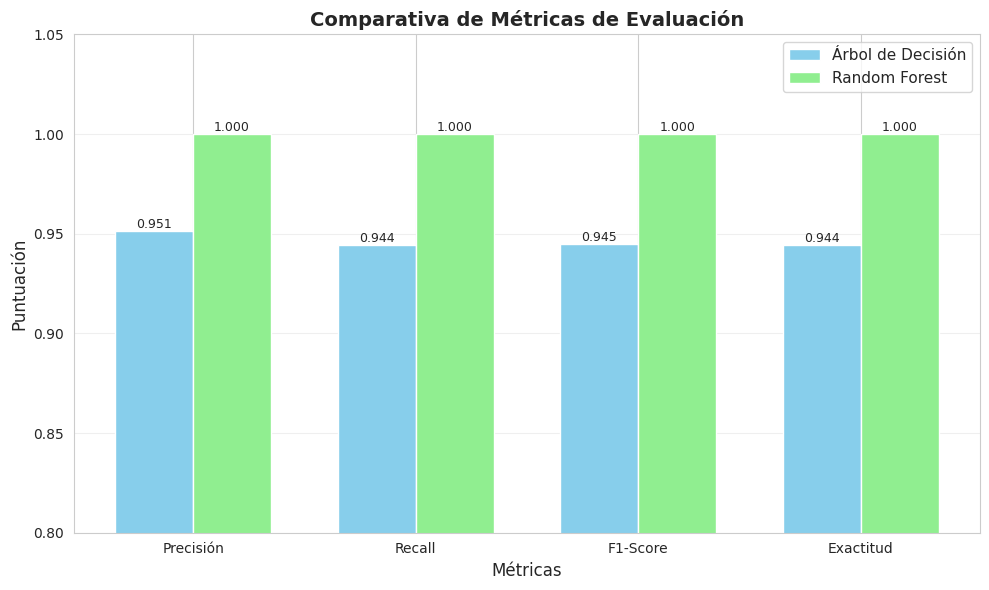

In [17]:
### 8.2 Visualización de Métricas
# Gráfico comparativo de métricas
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metricas_df))
width = 0.35

barras1 = ax.bar(x - width/2, metricas_df['Árbol Decisión'], width, label='Árbol de Decisión', color='skyblue')
barras2 = ax.bar(x + width/2, metricas_df['Random Forest'], width, label='Random Forest', color='lightgreen')

ax.set_xlabel('Métricas', fontsize=12)
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title('Comparativa de Métricas de Evaluación', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas_df['Métrica'])
ax.legend(fontsize=11)
ax.set_ylim([0.8, 1.05])
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for barras in [barras1, barras2]:
    for barra in barras:
        height = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
### 8.3 Métricas por Clase
print("\n" + "="*60)
print("ÁRBOL DE DECISIÓN - Métricas por Clase")
print("="*60)
print(classification_report(y_test, y_pred_dt, target_names=wine.target_names))

print("\n" + "="*60)
print("RANDOM FOREST - Métricas por Clase")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=wine.target_names))


ÁRBOL DE DECISIÓN - Métricas por Clase
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


RANDOM FOREST - Métricas por Clase
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



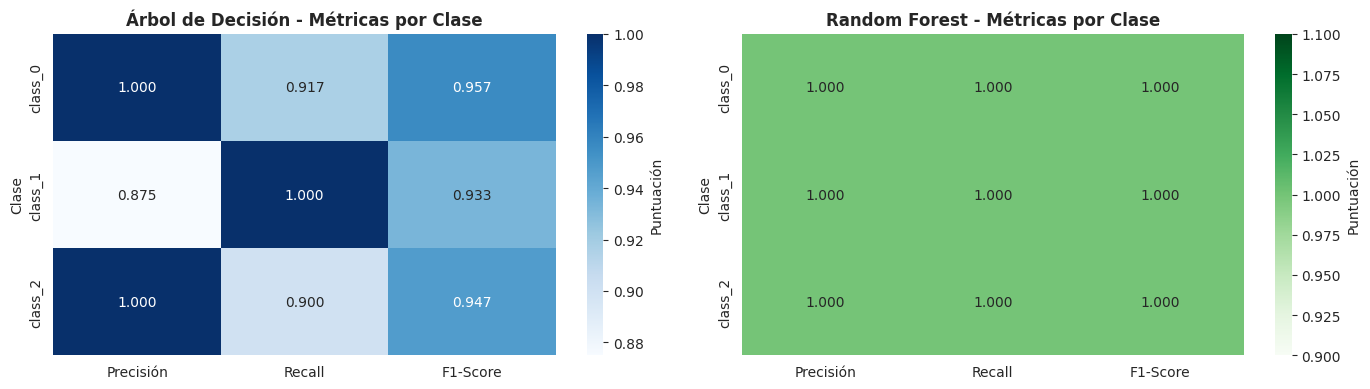

In [19]:
### 8.4 Heatmap de Métricas por Clase
# Obtener métricas individuales por clase
from sklearn.metrics import precision_recall_fscore_support

dt_precision_class, dt_recall_class, dt_f1_class, _ = precision_recall_fscore_support(y_test, y_pred_dt)
rf_precision_class, rf_recall_class, rf_f1_class, _ = precision_recall_fscore_support(y_test, y_pred_rf)

# Crear dataframes para visualización
dt_metrics_class = pd.DataFrame({
    'Clase': wine.target_names,
    'Precisión': dt_precision_class,
    'Recall': dt_recall_class,
    'F1-Score': dt_f1_class
})

rf_metrics_class = pd.DataFrame({
    'Clase': wine.target_names,
    'Precisión': rf_precision_class,
    'Recall': rf_recall_class,
    'F1-Score': rf_f1_class
})

# Visualización de heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap Árbol de Decisión
dt_heatmap_data = dt_metrics_class.set_index('Clase')[['Precisión', 'Recall', 'F1-Score']]
sns.heatmap(dt_heatmap_data, annot=True, fmt='.3f', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Puntuación'})
axes[0].set_title('Árbol de Decisión - Métricas por Clase', fontweight='bold')

# Heatmap Random Forest
rf_heatmap_data = rf_metrics_class.set_index('Clase')[['Precisión', 'Recall', 'F1-Score']]
sns.heatmap(rf_heatmap_data, annot=True, fmt='.3f', cmap='Greens', ax=axes[1], cbar_kws={'label': 'Puntuación'})
axes[1].set_title('Random Forest - Métricas por Clase', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
### 8.5 Resumen Completo de Métricas
# Crear tabla resumen con todas las métricas
resumen_metricas = pd.DataFrame({
    'Métrica': [
        'Exactitud (Accuracy)',
        'Precisión Ponderada',
        'Recall Ponderado',
        'F1-Score Ponderado'
    ],
    'Árbol Decisión': [
        f'{dt_accuracy:.4f}',
        f'{dt_precision:.4f}',
        f'{dt_recall:.4f}',
        f'{dt_f1:.4f}'
    ],
    'Random Forest': [
        f'{rf_accuracy:.4f}',
        f'{rf_precision:.4f}',
        f'{rf_recall:.4f}',
        f'{rf_f1:.4f}'
    ]
})

print("\n" + "="*70)
print("RESUMEN COMPLETO DE MÉTRICAS (Profundidad = 5)")
print("="*70)
print(resumen_metricas.to_string(index=False))
print("="*70)

# Determinar mejor modelo
print("\n📊 CONCLUSIONES:")
if rf_accuracy > dt_accuracy:
    print(f"✓ Random Forest tiene mejor exactitud ({rf_accuracy:.4f} vs {dt_accuracy:.4f})")
else:
    print(f"✓ Árbol de Decisión tiene mejor exactitud ({dt_accuracy:.4f} vs {rf_accuracy:.4f})")

if rf_f1 > dt_f1:
    print(f"✓ Random Forest tiene mejor F1-Score ({rf_f1:.4f} vs {dt_f1:.4f})")
else:
    print(f"✓ Árbol de Decisión tiene mejor F1-Score ({dt_f1:.4f} vs {rf_f1:.4f})")



RESUMEN COMPLETO DE MÉTRICAS (Profundidad = 5)
             Métrica Árbol Decisión Random Forest
Exactitud (Accuracy)         0.9444        1.0000
 Precisión Ponderada         0.9514        1.0000
    Recall Ponderado         0.9444        1.0000
  F1-Score Ponderado         0.9450        1.0000

📊 CONCLUSIONES:
✓ Random Forest tiene mejor exactitud (1.0000 vs 0.9444)
✓ Random Forest tiene mejor F1-Score (1.0000 vs 0.9450)
